In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Ensure the notebook can find the /src directory
root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

In [2]:
from src.data_loader import VesselDataLoader
from src.data_processing import DataProcessor
from src.regime_classifier import BayesianHMMClassifier

c:\Users\ext-adam\Desktop\INTERNSHIP\Mariner\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Path to your raw telemetry
raw_data_file1 = root_path / "data" / "raw" / "Rotherhithe_voy_179.csv"
raw_data_file2 = root_path / "data" / "raw" / "Wembley_voy_236.csv"

# Instantiate
loader1 = VesselDataLoader(raw_data_file1)
loader2 = VesselDataLoader(raw_data_file2)

# Load and clean the data
raw_df1 = loader1.load_and_clean()
raw_df2 = loader2.load_and_clean()

# Apply the Aggressive Butterworth strategy
processor = DataProcessor(raw_df2)
processed_df = processor.extract_features_and_filter(
    filter_method='butter', 
    cutoff=0.05, 
    order=2
)

In [11]:
# Isolate our pruned 6-feature orthogonal matrix
continuous_features = [
    'AE_POWER(kW)', 'ENERGY_INTENSITY', 
    'MANEUVER_INTENSITY', 'POWER_TV_ENERGY', 'PF_DERIVATIVE'
]
discrete_features = ['NUM_GENERATORS']

X_cont = processed_df[continuous_features].values
X_disc = processed_df[discrete_features].values.flatten()

# 2. Define the Experimental Matrix
experiments = [
    {"name": "SVI_ELA_K3_W1", "K": 3, "inertia": 1.0, "method": "svi"},
    {"name": "HMC_ELA_K3_W1", "K": 3, "inertia": 1.0, "method": "hmc"},
]

results_archive = []

print(f"Dataset ready. T={len(processed_df)} timesteps (approx {len(processed_df)*5/60:.1f} hours).")

Dataset ready. T=3167 timesteps (approx 263.9 hours).


In [12]:
results_archive = []

for exp in experiments:
    print(f"\n>>> Launching Experiment: {exp['name']}")
    
    # 1. Instantiate the modular Bayesian Classifier
    hmm = BayesianHMMClassifier(n_components=exp['K'], inertia_weight=exp['inertia'])
    
    # 2. Fit using the internal logic (Scales continuous features internally)
    # kwargs are passed to SVI (steps) or HMC (samples)
    if exp['method'] == 'svi':
        hmm.fit(X_cont, X_disc, method='svi', num_steps=5000)
    else:
        hmm.fit(X_cont, X_disc, method='hmc', num_warmup=300, num_samples=500)
    
    # 3. Viterbi Decoding
    state_sequence = hmm.predict(X_cont, X_disc)
    processed_df[f"STATE_{exp['name']}"] = state_sequence
    
    # 4. Calculate Physical Metrics for WP9 Extraction
    transitions = np.sum(state_sequence[1:] != state_sequence[:-1])
    # Dwell time is critical to ensure we don't subject the 1MW stack to non-physical jitter
    mean_dwell_hrs = (len(X_cont) / max(transitions, 1)) * (5 / 60)
    
    # Check for State Collapse
    unique_states, counts = np.unique(state_sequence, return_counts=True)
    active_k = len(unique_states)
    state_dist = {f"State_{k}": f"{(c/len(state_sequence))*100:.1f}%" for k, c in zip(unique_states, counts)}
    
    results_archive.append({
        "Experiment": exp['name'],
        "Method": exp['method'],
        "K_Target": exp['K'],
        "K_Active": active_k,
        "Mean_Dwell_Hr": round(mean_dwell_hrs, 2),
        "Transitions": transitions,
        "States": unique_states.tolist(),
        "Distribution": state_dist
    })

# Generate the comparison report
print("\n# MARINER HMM Inference Comparison")
print(pd.DataFrame(results_archive).to_markdown(index=False))


>>> Launching Experiment: SVI_ELA_K3_W1
Warm-starting SVI means with KMeans (K=3)...
Running SVI...


100%|██████████| 5000/5000 [00:26<00:00, 190.12it/s, init loss: 39678.7578, avg. loss [4751-5000]: 443.3905]  



>>> Launching Experiment: HMC_ELA_K3_W1
Running Hamiltonian Monte Carlo (Warmup: 300, Samples: 500)...


sample: 100%|██████████| 800/800 [50:43<00:00,  3.80s/it, 599 steps of size 1.02e-05. acc. prob=0.46]  



# MARINER HMM Inference Comparison
| Experiment    | Method   |   K_Target |   K_Active |   Mean_Dwell_Hr |   Transitions | States    | Distribution                                                 |
|:--------------|:---------|-----------:|-----------:|----------------:|--------------:|:----------|:-------------------------------------------------------------|
| SVI_ELA_K3_W1 | svi      |          3 |          3 |            7.54 |            35 | [0, 1, 2] | {'State_0': '29.0%', 'State_1': '71.0%', 'State_2': '0.0%'}  |
| HMC_ELA_K3_W1 | hmc      |          3 |          3 |            1.02 |           258 | [0, 1, 2] | {'State_0': '53.7%', 'State_1': '22.5%', 'State_2': '23.8%'} |




# MARINER Bayesian HMM Topology Report

*(Evaluating thermodynamic and mechanical inertia constraints for WP9 profile extraction)*

| Experiment    | Method   |   K_Target |   K_Active |   Mean_Dwell_Hr |   Transitions | States    |
|:--------------|:---------|-----------:|-----------:|----------------:|--------------:|:----------|
| SVI_ELA_K3_W1 | svi      |          3 |          3 |            7.54 |            35 | [0, 1, 2] |
| HMC_ELA_K3_W1 | hmc      |          3 |          3 |            1.02 |           258 | [0, 1, 2] |

## State Probability Mass Distribution
- **SVI_ELA_K3_W1**: {'State_0': '29.0%', 'State_1': '71.0%', 'State_2': '0.0%'}
- **HMC_ELA_K3_W1**: {'State_0': '53.7%', 'State_1': '22.5%', 'State_2': '23.8%'}


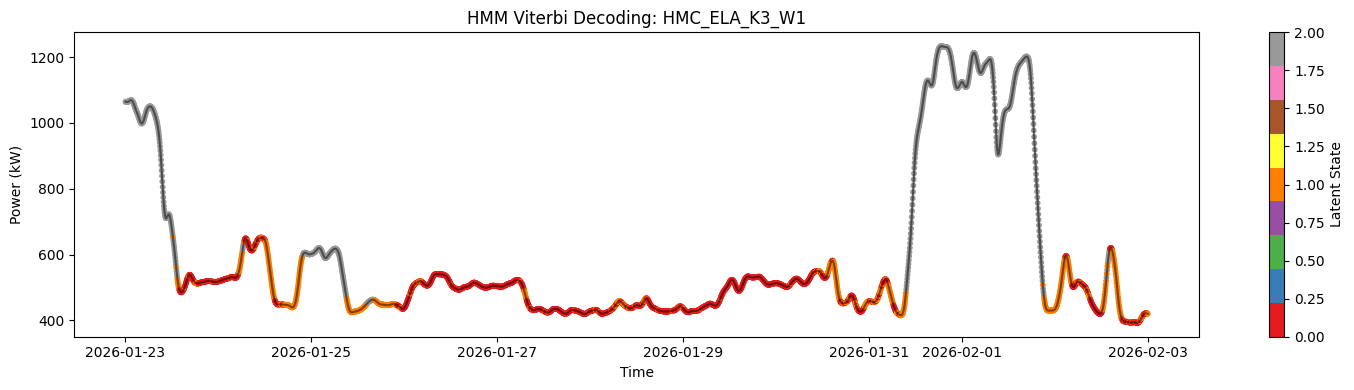

In [13]:
results_df = pd.DataFrame(results_archive)

print("\n\n# MARINER Bayesian HMM Topology Report\n")
print("*(Evaluating thermodynamic and mechanical inertia constraints for WP9 profile extraction)*\n")
print(results_df.drop(columns=['Distribution']).to_markdown(index=False))

print("\n## State Probability Mass Distribution")
for res in results_archive:
    print(f"- **{res['Experiment']}**: {res['Distribution']}")

# 5. Visualizing the Sequence (Optional but recommended)
# Pick the best performing model and plot the state timeline over AE_POWER
best_model_name = "HMC_ELA_K3_W1" # Change based on your analysis
plt.figure(figsize=(15, 4))
plt.plot(processed_df.index, processed_df['AE_POWER(kW)'], label="AE Power", color="black", alpha=0.5)
sc = plt.scatter(processed_df.index, processed_df['AE_POWER(kW)'], c=processed_df[f"STATE_{best_model_name}"], cmap='Set1', s=10)
plt.colorbar(sc, label="Latent State")
plt.title(f"HMM Viterbi Decoding: {best_model_name}")
plt.ylabel("Power (kW)")
plt.xlabel("Time")
plt.tight_layout()
plt.show()

In [ ]:
# import sys
# from pathlib import Path
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# # Import your custom classes
# from src.data_processor import DataProcessor
# from src.regime_classifier import BayesianHMMClassifier
# from src.visualizer import VesselVisualizer

# # 1. Define Features
# continuous_features = [
#     'AE_POWER(kW)', 'ENERGY_INTENSITY', 
#     'MANEUVER_INTENSITY', 'POWER_TV_ENERGY', 'PF_DERIVATIVE'
# ]
# discrete_features = ['NUM_GENERATORS']

# X_cont = processed_df[continuous_features].values
# X_disc = processed_df[discrete_features].values.flatten()

# # 2. Define the Experimental Matrix
# # We mix SVI (with our new KMeans warm-start) and HMC to test true dimensionality
# experiments = [
#     {"name": "SVI_Warm_K4_W50", "K": 4, "inertia": 50.0, "method": "svi", "steps": 3000},
#     {"name": "SVI_Warm_K3_W150", "K": 3, "inertia": 150.0, "method": "svi", "steps": 3000},
#     {"name": "HMC_Rigorous_K3_W150", "K": 3, "inertia": 150.0, "method": "hmc", "warmup": 300, "samples": 500},
# ]

# results_archive = []

# print(f"Dataset ready. T={len(processed_df)} timesteps (approx {len(processed_df)*5/60:.1f} hours).")

# # 3. Execution Loop
# for exp in experiments:
#     print(f"\n>>> Launching Experiment: {exp['name']}")
    
#     # Instantiate the classifier
#     hmm = BayesianHMMClassifier(n_components=exp['K'], inertia_weight=exp['inertia'])
    
#     # Fit the model
#     if exp['method'] == 'svi':
#         hmm.fit(X_cont, X_disc, method='svi', num_steps=exp['steps'])
#         hmm.plot_loss() # NEW: Visually check convergence
#     else:
#         hmm.fit(X_cont, X_disc, method='hmc', num_warmup=exp['warmup'], num_samples=exp['samples'])
    
#     # Predict the optimal path
#     state_sequence = hmm.predict(X_cont, X_disc)
#     predicted_col_name = f"STATE_{exp['name']}"
#     processed_df[predicted_col_name] = state_sequence
    
#     # NEW: Generate the deep-dive physical diagnostics report
#     state_df = hmm.generate_diagnostics(X_cont, state_sequence, continuous_features)
    
#     # Calculate high-level metrics for the summary table
#     transitions = np.sum(state_sequence[1:] != state_sequence[:-1])
#     mean_dwell_hrs = (len(X_cont) / max(transitions, 1)) * (5 / 60)
#     unique_states = np.unique(state_sequence)
    
#     results_archive.append({
#         "Experiment": exp['name'],
#         "Method": exp['method'].upper(),
#         "K_Target": exp['K'],
#         "K_Active": len(unique_states),
#         "Mean_Dwell_Hr": round(mean_dwell_hrs, 2),
#         "Transitions": transitions
#     })

# # 4. Global Summary Report
# print("\n" + "="*50)
# print("MARINER HMM INFERENCE COMPARISON")
# print("="*50)
# print(pd.DataFrame(results_archive).to_markdown(index=False))

# # 5. Visualizing the Sequence with VesselVisualizer
# # Pick the best performing model to visualize
# best_model_col = f"STATE_{experiments[1]['name']}" 

# print(f"\nGenerating unified visualization for {best_model_col}...")
# viz = VesselVisualizer(processed_df)

# # We pass the continuous features, smooth them over 6 ticks (30 mins),
# # use the human 'STATUS' for background colors, and our new HMM column for the step plot.
# fig, axes = viz.plot_series(
#     columns=['AE_POWER(kW)', 'POWER_TV_ENERGY'], 
#     subplots=True,
#     rolling_window=6, 
#     status_col='STATUS', 
#     predicted_col=best_model_col
# )